In [1]:
%load_ext ipympl
%matplotlib widget

import numpy as np
import importlib, game_3dutils, ukf_estimator,game_viz, game_runner, rl_loop #game_runner_mcp,  rl_infer
from pathlib import Path
import shutil
import matplotlib.pyplot as plts

import torch
import os

import rl_infer

importlib.reload(game_3dutils)
importlib.reload(ukf_estimator)
importlib.reload(game_viz)
importlib.reload(rl_loop)
importlib.reload(rl_infer)
importlib.reload(game_runner)
# importlib.reload(game_runner_mcp)


# from game_3dutils    import run_rhc_and_collect_frames_3d, run_rhc_with_rl_and_collect_frames_3d
from game_runner import run_rhc_with_rl_and_collect_frames_3d#, run_rhc_with_rl_and_collect_frames_3d_1v2
# from game_costs import build_game_costs
from game_viz import animate_rollout_3d, interactive_rollout_3d, plot_rollout_thrust_u, plot_rollout_center_distance, plot_rollout_relative_distance

from game_viz_multi import plot_rollout_thrust_u_multi, interactive_rollout_3d_multi, plot_rollout_center_distance_multi


from dyn_models import (
    hcw_mean_motion, hcw_discrete_mats, as_numpy_const, dims_from_D,
    augment_AB_for_att, augment_bounds_with_att, pad_x0_with_att,
    frame_from_axis_continuous, world_to_body_R, apply_roll_about_axis
)

from paper_baseline_runner import (
    run_rhc_with_paper_game_1v1_collect_frames_3d,
    run_rhc_with_paper_game_1v2_collect_frames_3d,
)

from config_rl import config_for_eval, build_dyn


The ipympl module is not an IPython extension.


In [2]:
import copy
import json

CKPT_DIR = Path("Training_Policy")

# POLICY_DEFENDER = "def0_def_teacher.pt"             # "def#_def_ukf_student.pt" or "def#_def_teacher.pt"
POLICY_DEFENDER = "def0_teacher.pt"             # "def#_def_ukf_student.pt" or "def#_def_teacher.pt"
POLICY_ATTACKER = "att1_teacher.pt"
ATTACKER_MODE = "rule" # "rule" or "rl"
USE_KF = False  # True or False
ESTIMATOR_KIND = "ukf"  # "ukf" | "ekf"
KF_ACTION_ACCESS = "ground_truth"  # "ground_truth" | "measured" | "none"
KF_ACTION_MEAS_STD = None  # None => keep manifest/config default; scalar or length-3 sequence
ROLLOUT_DYNAMICS = "hcw"    # hcw, two_body, elliptic_ltv
DELTA_T = 0.1
TOTAL_ROLLOUT_TIME = 300 #Seconds

STARTING_STATES = np.array([
        [  -2.5, 0.0, 0.0,  +0.02, 0.00, 0.000],  # defender
        [ -19.9, 0.0, 0.0,  +0.02, 0.00, 0.000], # attacker
    ], dtype=float)

ANIMATE_ROLLOUT = True
CREATE_GIF_AND_MP4 = False


def _load_manifest_training_cfg(run_dir: Path):
    manifest_path = run_dir / "run_manifest.json"
    if not manifest_path.is_file():
        raise RuntimeError(f"Missing run_manifest.json: {manifest_path}")

    manifest = json.loads(manifest_path.read_text())
    configs = manifest.get("configs") or {}
    cfg = configs.get("training config used")
    if not isinstance(cfg, dict):
        raise RuntimeError(
            f"Could not find dict-valued configs['training config used'] in {manifest_path}"
        )
    return copy.deepcopy(cfg), manifest_path


def _set_ckpt_overrides(cfg, def_ckpt: Path, att_ckpt: Path | None = None):
    def_str = str(def_ckpt)
    for k in ["def_ckpt_path", "def_ckpt", "def_policy_path", "defender_ckpt_path", "defender_ckpt", "ckpt_def"]:
        cfg[k] = def_str

    if att_ckpt is not None:
        att_str = str(att_ckpt)
        for k in ["att_ckpt_path", "att_ckpt", "att_policy_path", "attacker_ckpt_path", "attacker_ckpt", "ckpt_att"]:
            cfg[k] = att_str


def main():
    """
    Run one rollout using the current module-level CAPITALIZED knobs.
    Base config is loaded from CKPT_DIR/run_manifest.json, then notebook knobs
    are applied as explicit overrides on top.
    """
    import os
    import shutil
    from pathlib import Path

    import imageio.v3 as iio

    run_dir = Path(CKPT_DIR)
    cfg, manifest_path = _load_manifest_training_cfg(run_dir)

    # ---- Apply notebook overrides ----
    cfg["attacker_mode"] = ATTACKER_MODE
    cfg["x0"] = np.asarray(STARTING_STATES, dtype=float)
    cfg["use_kf"] = bool(USE_KF)
    cfg["estimator_kind"] = str(ESTIMATOR_KIND)
    cfg.setdefault("ukf", {})
    cfg["ukf"]["action_access"] = str(KF_ACTION_ACCESS)
    if KF_ACTION_MEAS_STD is not None:
        cfg["ukf"]["action_meas_std"] = KF_ACTION_MEAS_STD
    cfg["dynamics"] = ROLLOUT_DYNAMICS
    cfg["dt"] = float(DELTA_T)
    cfg["T"] = int(round(TOTAL_ROLLOUT_TIME / DELTA_T))

    # Fill Ad/Bd (float32) from chosen dynamics
    build_dyn(cfg)

    # ---- Checkpoints ----
    def_ckpt = run_dir / POLICY_DEFENDER
    att_ckpt = (run_dir / POLICY_ATTACKER) if (cfg.get("attacker_mode", "rule") == "rl" and POLICY_ATTACKER) else None
    _set_ckpt_overrides(cfg, def_ckpt, att_ckpt)

    print(f"manifest: {manifest_path}")
    print(
        "DEF ckpt?", os.path.exists(cfg["ckpt_def"]),
        "ATT ckpt?", os.path.exists(cfg.get("ckpt_att", "")),
        "| attacker_mode:", cfg.get("attacker_mode"),
        "| use_kf:", cfg.get("use_kf"),
        "| estimator_kind:", cfg.get("estimator_kind"),
        "| kf_action_access:", cfg.get("ukf", {}).get("action_access"),
        "| kf_action_meas_std:", cfg.get("ukf", {}).get("action_meas_std")
    )

    # ---- Run rollout ----
    steps = int(cfg["T"])
    print("steps:", steps)

    rollout = run_rhc_with_rl_and_collect_frames_3d(cfg, steps=steps)

    print("Finished rollout.")

    # ---- Animate & save ----
    if CREATE_GIF_AND_MP4:
        print("Starting animation...")
        if TOTAL_ROLLOUT_TIME < 121:  # seconds
            FILE_NAME = "traj_3D_rl_1vRL"
            GIF_PATH = str(run_dir / (FILE_NAME + ".gif"))
            MP4_PATH = str(run_dir / (FILE_NAME + ".mp4"))

            print("Saving to .gif...")
            animate_rollout_3d(
                rollout,
                save_path=GIF_PATH,
                fps=20,
                cfg=cfg,
                show_fov=True,
                show_axes=True,
            )

            print("Saving to .mp4...")
            gif_frames = iio.imread(GIF_PATH)
            iio.imwrite(MP4_PATH, gif_frames, fps=20, codec="h264")
            print("Saved:", GIF_PATH, "and", MP4_PATH)
        else:
            print("Skipping animation due to large rollout size...")

    # ---- Optional interactive viewer (blocks until you close it) ----
    if ANIMATE_ROLLOUT:
        print("Starting interactive rollout...")
        interactive_rollout_3d(rollout, cfg, show_fov=True, show_axes=True)

    # ---- Optional cleanup ----
    for p in Path(".").rglob("__pycache__"):
        shutil.rmtree(p, ignore_errors=True)
    for f in Path(".").rglob("*.pyc"):
        try:
            f.unlink()
        except FileNotFoundError:
            pass

    return rollout, cfg


def run_with(**overrides):
    old = {}
    for k, v in overrides.items():
        old[k] = globals()[k]
        globals()[k] = v
    try:
        return main()          # <-- this returns (rollout, cfg)
    finally:
        for k, v in old.items():
            globals()[k] = v


manifest: Training_Policy_0.75_EKF_BC_Meas_1m/run_manifest.json
DEF ckpt? True ATT ckpt? True | attacker_mode: rl | use_kf: True | estimator_kind: ekf | kf_action_access: measured | kf_action_meas_std: 1.0
steps: 3000
Finished rollout.
Starting interactive rollout...


/home/gs34433/Research/Research_Repo/game_viz.py:648: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(7, 6))


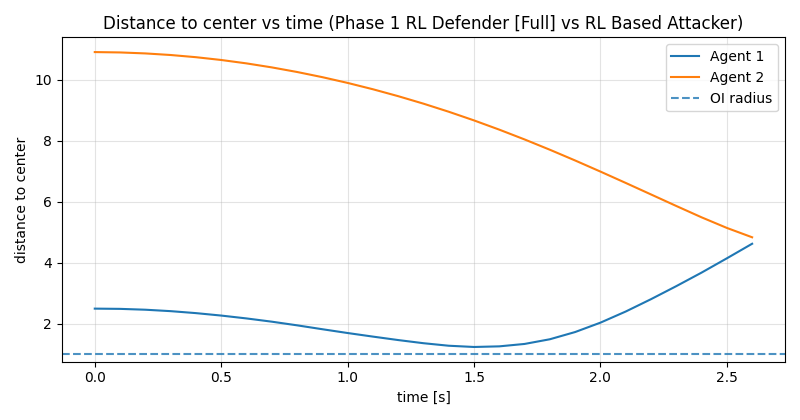

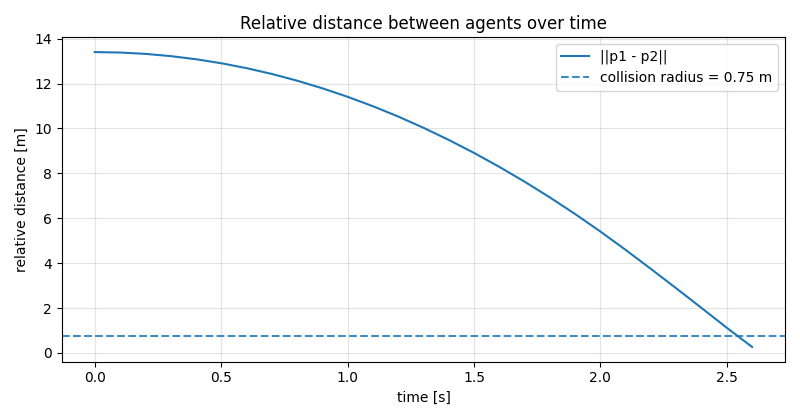

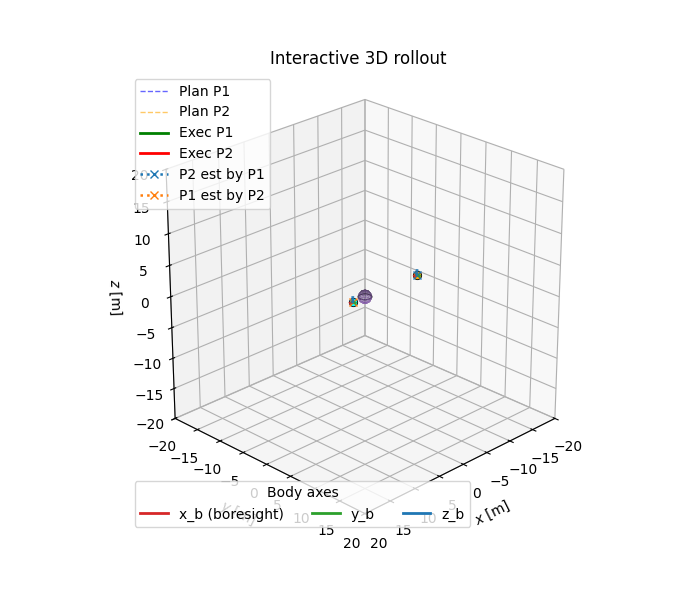

In [ ]:
if __name__ == "__main__":
    rollout, cfg = run_with(
        CKPT_DIR = Path("Training_Policy_0.75_EKF_BC_GT"),
        # POLICY_DEFENDER="def1_teacher__best.pt",
        POLICY_DEFENDER="def2_teacher.pt",
        POLICY_ATTACKER="att1_teacher.pt",
        ATTACKER_MODE="rl",

        STARTING_STATES=np.array([
            [  2.5, 0.0, 0.0,  +0.02, 0.00, 0.000],  # defender
            [ -10.9, 0.0, 0.0,  +0.02, 0.00, 0.000], # attacker
        ], dtype=float),

        USE_KF=True,
        ESTIMATOR_KIND="ekf",
        KF_ACTION_ACCESS = "measured", # "ground_truth", "measured", or "none"
        KF_ACTION_MEAS_STD = 1.0,
        ANIMATE_ROLLOUT=True
    )

    plot_rollout_center_distance(rollout, cfg, title = "Distance to center vs time (Phase 1 RL Defender [Full] vs RL Based Attacker)")
    plot_rollout_relative_distance(rollout, cfg, title="Relative distance between agents over time")


DEF ckpt? True ATT ckpt? True | attacker_mode: rl
steps: 3000
[rl_infer_diff] DEF: legacy checkpoint format detected; retrying torch.load(..., weights_only=False).
Finished rollout.


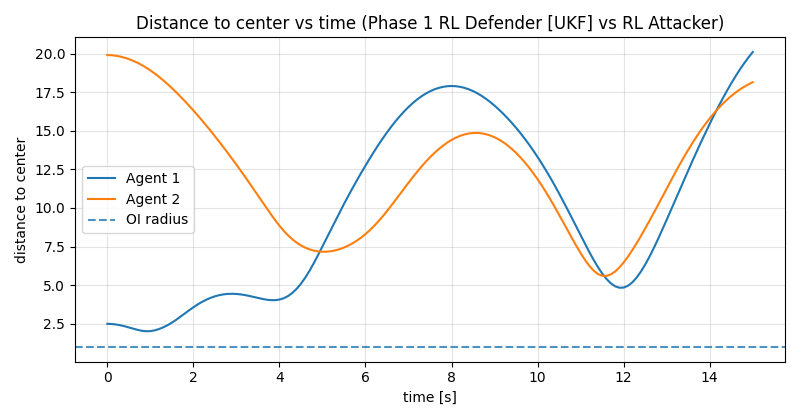

In [ ]:
if __name__ == "__main__":
    rollout, cfg = run_with(
        POLICY_DEFENDER="def2_teacher.pt",
        POLICY_ATTACKER="att1_teacher.pt",
        ATTACKER_MODE="rl",
        USE_KF=True,
        ESTIMATOR_KIND="ukf",
        ANIMATE_ROLLOUT=False
    )

    plot_rollout_center_distance(rollout, cfg, title = f"Distance to center vs time (Phase 1 RL Defender [{str(cfg.get('estimator_kind', 'ukf')).upper()}] vs RL Attacker)")

In [ ]:
# After you have frames_dict from a rollout:
plot_rollout_thrust_u(rollout, cfg=cfg, agent=1)

# Agent 2:
plot_rollout_thrust_u(rollout, cfg=cfg, agent=2)

In [ ]:
plot_rollout_center_distance(rollout, cfg)

# Multiattacker case

In [ ]:
CKPT_DIR = Path("Training_Policy_Pt1_MultiAttacker")

# --- MULTI-ATTACKER (1v2) knobs ---
NUM_ATTACKERS   = 2

POLICY_DEFENDER = "def0_teacher.pt"   # "def#_teacher.pt" / "def#_ukf_student.pt" etc.
POLICY_ATTACKER = "att1_teacher.pt"   # only used if ATTACKER_MODE=="rl"
ATTACKER_MODE   = "rule"                 # "rule" or "rl"

USE_KF            = False                  # True / False
ESTIMATOR_KIND    = "ukf"                # "ukf" | "ekf"
KF_ACTION_ACCESS  = "ground_truth"        # "ground_truth" | "measured" | "none"
KF_ACTION_MEAS_STD = None                  # None => keep config default; scalar or length-3 sequence
UKF_WHO          = "both"                 # "none" | "1->2" | "2->1" | "both"   (Level-A runner)
DEF_OBS_FROM     = "truth"                # "truth" | "ukf_each" | "ukf_primary" (Level-A runner)
PRIMARY_ATTACKER = "closest"              # "closest" | "idx0"                  (used by "ukf_primary")

ROLLOUT_DYNAMICS    = "hcw"               # hcw, two_body, elliptic_ltv
DELTA_T             = 0.1
TOTAL_ROLLOUT_TIME  = 300                 # seconds

ANIMATE_ROLLOUT     = True
CREATE_GIF_AND_MP4  = False


def main():
    """
    Run one 1v2 rollout using the current module-level CAPITALIZED knobs.
    Change the CAPITALIZED variables at the top of the file (or via run_with()),
    then call main().

    Expects:
      - config_for_eval, build_dyn in scope
      - run_rhc_with_rl_and_collect_frames_3d_1v2 in scope
      - animate_rollout_3d, interactive_rollout_3d (optional)
    """
    import os
    import shutil
    from pathlib import Path

    import numpy as np

    # Only needed if you actually use GIF/MP4 writing
    import imageio.v3 as iio

    # ---- Build cfg ----
    cfg = config_for_eval(
        attacker_mode=ATTACKER_MODE,  # "rule" or "rl"
    )

    # ---- 1v2 ----
    cfg["num_attackers"] = int(NUM_ATTACKERS)

    # Example ICs (def, att0, att1). You can change these.
    # If you only provide 2 rows, some runners may clone att0 -> att1; better to pass 3 rows explicitly.
    # cfg["x0"] = np.array([
    #     [  2.5,  0.0, 0.0,  -0.02, 0.00, 0.000],  # defender
    #     [ -19.9, 0.0, 0.0,  +0.02, 0.00, 0.000],  # attacker 0
    #     [ -10.5, 10.0, 0.0,  +0.02, 0.00, 0.000],  # attacker 1
    # ], dtype=float)

    cfg["x0"] = np.array([
        [  2.5,  0.0, 0.0,  -0.02, 0.00, 0.000],  # defender
        [ -19.9, 0.0, 0.0,  +0.02, 0.00, 0.000],  # attacker 0
        [ 10.5, 10.0, 0.0,  +0.02, 0.00, 0.000],  # attacker 1
    ], dtype=float)

    # ---- Apply rollout knobs ----
    cfg["use_kf"]    = bool(USE_KF)
    cfg["estimator_kind"] = str(ESTIMATOR_KIND)
    cfg["dynamics"]  = ROLLOUT_DYNAMICS
    cfg["dt"]        = DELTA_T

    # Level-A runner estimator options (stored under cfg["ukf"], safe even if USE_KF=False)
    cfg.setdefault("ukf", {})
    cfg["ukf"]["who"] = UKF_WHO
    cfg["ukf"]["action_access"] = str(KF_ACTION_ACCESS)
    if KF_ACTION_MEAS_STD is not None:
        cfg["ukf"]["action_meas_std"] = KF_ACTION_MEAS_STD
    cfg["runner_def_obs_from"] = DEF_OBS_FROM
    cfg["runner_primary_attacker"] = PRIMARY_ATTACKER

    # Make horizon an INT number of steps (avoid float weirdness)
    cfg["T"] = int(round(TOTAL_ROLLOUT_TIME / DELTA_T))

    # Fill Ad/Bd (float32) from chosen dynamics
    build_dyn(cfg)

    # ---- Checkpoints ----
    cfg["ckpt_def"] = str(CKPT_DIR / POLICY_DEFENDER)

    # Only set attacker ckpt when attacker_mode is RL and you provided a filename
    if cfg.get("attacker_mode", "rule") == "rl" and POLICY_ATTACKER:
        cfg["ckpt_att"] = str(CKPT_DIR / POLICY_ATTACKER)

    print(
        "DEF ckpt?", os.path.exists(cfg["ckpt_def"]),
        "ATT ckpt?", os.path.exists(cfg.get("ckpt_att", "")),
        "| attacker_mode:", cfg.get("attacker_mode"),
        "| num_attackers:", cfg.get("num_attackers"),
        "| use_kf:", cfg.get("use_kf"),
        "| estimator_kind:", cfg.get("estimator_kind"),
        "| kf_action_access:", cfg.get("ukf", {}).get("action_access"),
        "| kf_action_meas_std:", cfg.get("ukf", {}).get("action_meas_std"),
    )

    # ---- Run rollout ----
    steps = int(cfg["T"])
    print("steps:", steps)

    rollout = run_rhc_with_rl_and_collect_frames_3d_1v2(cfg, steps=steps)

    print("Finished rollout.")

    # ---- Animate & save ----
    if CREATE_GIF_AND_MP4:
        print("Starting animation...")
        if TOTAL_ROLLOUT_TIME < 121:  # seconds
            FILE_NAME = "traj_3D_rl_1v2"
            GIF_PATH = str(CKPT_DIR / (FILE_NAME + ".gif"))
            MP4_PATH = str(CKPT_DIR / (FILE_NAME + ".mp4"))

            print("Saving to .gif...")
            animate_rollout_3d_multi(
                rollout,
                save_path=GIF_PATH,
                fps=20,
                cfg=cfg,
                show_fov=True,
                show_axes=True,
            )

            print("Saving to .mp4...")
            gif_frames = iio.imread(GIF_PATH)
            iio.imwrite(MP4_PATH, gif_frames, fps=20, codec="h264")
            print("Saved:", GIF_PATH, "and", MP4_PATH)
        else:
            print("Skipping animation due to large rollout size...")

    # ---- Optional interactive viewer (blocks until you close it) ----
    if ANIMATE_ROLLOUT:
        print("Starting interactive rollout...")
        interactive_rollout_3d_multi(rollout, cfg, show_fov=True, show_axes=True)

    # ---- Optional cleanup ----
    for p in Path(".").rglob("__pycache__"):
        shutil.rmtree(p, ignore_errors=True)
    for f in Path(".").rglob("*.pyc"):
        try:
            f.unlink()
        except FileNotFoundError:
            pass

    return rollout, cfg


def run_with_multi(**overrides):
    old = {}
    for k, v in overrides.items():
        old[k] = globals()[k]
        globals()[k] = v
    try:
        return main()          # returns (rollout, cfg)
    finally:
        for k, v in old.items():
            globals()[k] = v

In [ ]:
if __name__ == "__main__":
    rollout_multi, cfg_multi = run_with_multi(
        CKPT_DIR = Path("Training_Policy"),
        POLICY_DEFENDER="def1_teacher.pt",
        POLICY_ATTACKER="att1_teacher.pt",
        ATTACKER_MODE="rl",
        USE_KF=False,
        ESTIMATOR_KIND="ukf",
        ANIMATE_ROLLOUT=False
    )

In [ ]:
plot_rollout_center_distance_multi(rollout_multi, cfg_multi, agents=(1,2,3))

# Chinese paper baseline:

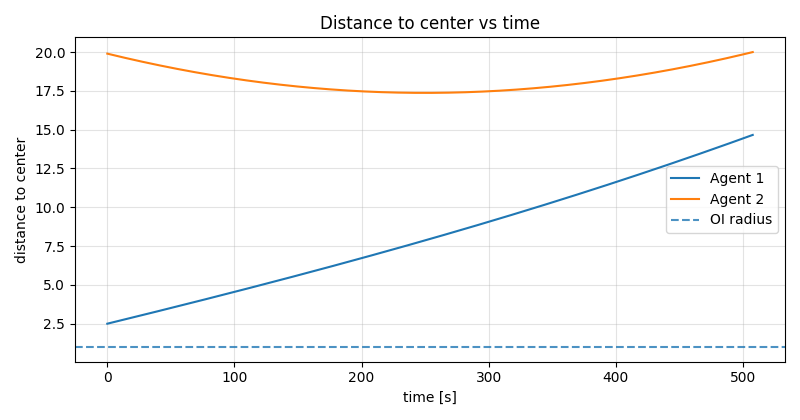

(<Figure size 800x420 with 1 Axes>,
 <Axes: title={'center': 'Distance to center vs time'}, xlabel='time [s]', ylabel='distance to center'>)

In [4]:
ANIMATE_ROLLOUT = True

cfg = config_for_eval(attacker_mode="rule")   # attacker_mode irrelevant here; we don’t use RL policies
cfg["dynamics"] = "hcw"
cfg["dt"] = 0.1

TOTAL_TIME = 1000
cfg["T"] = int(round(TOTAL_TIME / cfg["dt"]))

# Paper knobs

cfg["umax"] = 5e-4
cfg["paper"] = {
    "Nup": 3, "Nue": 3,
    "dup": 1e-3, "due": 1e-3,
    "tau": 5,
    "beta1": 0.5, "beta2": 0.5,
    "dsafe": 3.0,
    "max_ars_iter": 30,
}

#Custom

# cfg["umax"] = 2.0

# cfg["paper"] = {
#   "Nup": 5, "Nue": 5,
#   "dup": 0.2 * cfg["umax"],
#   "due": 0.2 * cfg["umax"],
#   "tau": 20,
#   "dsafe": 1.0,
# }



#
cfg["paper_baseline"] = {
    "objective": "ppo_oi_minmax",
    "ppo_obj": {
        "threat_mode": "closest_to_center",  # or "idx0"
        # optional overrides; otherwise pulled from cfg keys if present:
        # "alpha": ..., "k_pos": ..., "lD": ..., "wallK": ..., "soft_wall": ...,
        # "oi_radius_m": ..., "def_keepout_buffer_m": ..., "def_center_avoid_coef": ...
    }
}

# 1v1 initial state
cfg["x0"] = np.array([
    [  -2.5, 0.0, 0.0,  -0.02, 0.00, 0.000],  # evader (def)
    [ -19.9,0.0, 0.0,  +0.02, 0.00, 0.000],  # pursuer (att)
], dtype=float)

build_dyn(cfg)
steps = int(cfg["T"])
rollout = run_rhc_with_paper_game_1v1_collect_frames_3d(cfg, steps=steps)
plot_rollout_center_distance(rollout, cfg)



# ---- Optional interactive viewer (blocks until you close it) ----
# if ANIMATE_ROLLOUT:
#     print("Starting interactive rollout...")
#     interactive_rollout_3d(rollout, cfg, show_fov=True, show_axes=True)

# # 1v2: add a third row for attacker1
# cfg["x0"] = np.array([
#     [  2.5, 0.0, 0.0,  -0.02, 0.00, 0.000],
#     [ -19.9,0.0, 0.0,  +0.02, 0.00, 0.000],
#     [ -18.0,2.0, 0.0,  +0.02, 0.00, 0.000],
# ], dtype=float)
# cfg["num_attackers"] = 2
# build_dyn(cfg)
# rollout_1v2 = run_rhc_with_paper_game_1v2_collect_frames_3d(cfg, steps=300)

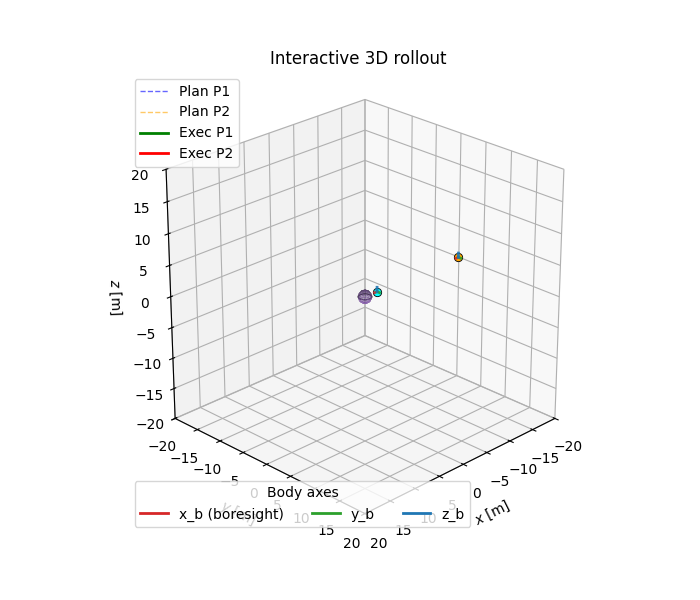

In [ ]:
# interactive_rollout_3d(rollout, cfg, show_fov=True, show_axes=True)


# MCP Rollout

In [1]:
from config_rl import config_for_eval
from mcp_baseline_runner import run_rhc_with_mcp_game_1v1_collect_frames_3d
import numpy as np

cfg_mcp = config_for_eval(attacker_mode="rl")
cfg_mcp["dynamics"] = "double_integrator"
cfg_mcp["dt"] = 1.0
cfg_mcp["T"] = 120
cfg_mcp["stop_on_done"] = False
cfg_mcp["arena"]["r"] = 10.0
cfg_mcp["oi"]["r"] = 0.1

cfg_mcp["x0"] = np.array([
    [0.0, 3.0, 0.0, -0.05, -0.05, -0.05],
    [1.0, 0.0, 0.0, -0.05, -0.05, -0.05],
], dtype=float)
cfg_mcp["mcp"] = {
    "mode": "balloon_capture",
    "solver": "path",
    "executable": "/home/gs34433/Research/path_5/ampl/pathampl",
    "tee": False,
    "pred_horizon": 10,
    "turn_len": 2,
    "stage_discount": 1.0,
    "defender_umax": 10.0,
    "attacker_umax": 1.0,
    "include_env_constraints": True,
}

rollout_mcp = run_rhc_with_mcp_game_1v1_collect_frames_3d(cfg_mcp, steps=90)
plot_rollout_center_distance(rollout_mcp, cfg_mcp, title = "Distance to center vs time (MCP)")
# plot_rollout_relative_distance(rollout_mcp, cfg_mcp, title="Relative distance between agents over time")

ERROR: Constructing component 'st_u1' from data=None failed:
        KeyboardInterrupt:


KeyboardInterrupt: 

In [26]:
rollout_mcp["mcp_dbg_hist"][:3]
rollout_mcp["u_cmd_norm_all"][0][:10], rollout_mcp["u_cmd_norm_all"][1][:10]


(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0.00045672, 0.00051783, 0.000526  , 0.0005271 , 0.00052724,
        0.00052726, 0.00052727, 0.00052727, 0.00052727, 0.00052727]))

# Test baselines

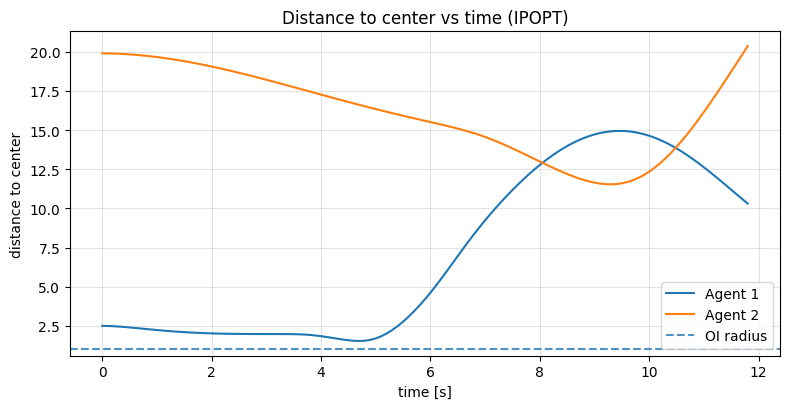

In [66]:
from config_rl import config_for_eval
from IPOPT_baseline import run_rhc_with_ipopt_game_1v1_collect_frames_3d
from GameTheory_baseline import run_rhc_with_gametheory_game_1v1_collect_frames_3d

ROLLOUT_DYNAMICS    = "hcw"               # hcw, two_body, elliptic_ltv
TOTAL_ROLLOUT_TIME  = 300                 # seconds
DELTA_T             = 0.1

T_EVAL = TOTAL_ROLLOUT_TIME/DELTA_T


cfg = config_for_eval(T=15, T_eval=T_EVAL, num_attackers=1, dt = DELTA_T)


# #Current
# cfg["paper_baseline"] = {
#     "zero_sum": {
#         "lookahead": 10,
#         "include_terminal": True,
#         "include_step_walls": False,
#         "include_keepout": False,
#         "objective_mode": "discounted_sum",
#     }
# }

cfg["paper_baseline"] = {
    "zero_sum": {
        "lookahead": 10,
        "include_terminal": True,
        "include_step_walls": True,
        "include_keepout": True,
    }
}




#Working
# cfg["paper_baseline"] = {
#     "zero_sum": {
#         "lookahead": 10,
#         "include_terminal": True,
#         "include_step_walls": True,
#         "include_keepout": True,
#     }
# }


# "PPO like"
# cfg["paper_baseline"] = {
#     "zero_sum": {
#         "lookahead": 1,
#         "include_terminal": True,
#         "include_step_walls": False,
#         "include_keepout": False,
#     }
# }


# cfg["oi"] = {"enabled": True, "r": 1.0}
# cfg["def_keepout_buffer_m"] = 1.0
# cfg["def_center_avoid_coef"] = 50.0
# cfg["target_hit_reward_penalty"] = 10.0
# cfg["wall_penalty"] = 10.0
# cfg["collision_penalty"] = 10.0

cfg["ipopt_baseline"] = {
    "br_iters": 20,
    "subproblem_max_iter": 200,
    "tol": 1e-8,
    "fd_eps": 1e-3,
    "reg_prev": 1e-8,
}

cfg["game_theory_baseline"] = {
    "max_iters": 300,
    "step_size_def": 5e-2,
    "step_size_att": 5e-2,
    "fd_eps": 1e-3,
    "tol": 1e-8,
    "reg_prev": 1e-8,
}

cfg["effort_def"] = 0.01
cfg["effort_att"] = 0.01


# cfg["wall_penalty"] = 25.0
# cfg["collision_penalty"] = 25.0
# cfg["target_hit_reward_penalty"] = 15.0
cfg["def_center_avoid_coef"] = 50.0
cfg["def_keepout_buffer_m"] = 1.0


from IPython.display import display
import matplotlib.pyplot as plt

frames_ipopt = run_rhc_with_ipopt_game_1v1_collect_frames_3d(cfg)
fig1, ax1 = plot_rollout_center_distance(
    frames_ipopt, cfg, title="Distance to center vs time (IPOPT)", show=False
)
display(fig1)
plt.close(fig1)


In [ ]:
frames_gt = run_rhc_with_gametheory_game_1v1_collect_frames_3d(cfg)
fig2, ax2 = plot_rollout_center_distance(
    frames_gt, cfg, title="Distance to center vs time (Game Theory)", show=False
)
display(fig2)
plt.close(fig2)

KeyboardInterrupt: 

# Replay Timeout / No-Capture Cases

Use the next cell to load one row from `timeout_no_capture_cases.csv`, rebuild the exact initial state, and run the rollout/animation with the saved training config from that run manifest.


In [ ]:
from pathlib import Path
import copy
import csv
import json
import numpy as np

TIMEOUT_CASES_CSV = Path("Training_Policy_0.75/MC_eval/def2_vs_att2/timeout_no_capture_cases.csv")
TIMEOUT_CASE_INDEX = 0
REPLAY_DEF_CKPT = Path("Training_Policy_0.75/def2_teacher.pt")
REPLAY_ATT_CKPT = Path("Training_Policy_0.75/att2_teacher.pt")
REPLAY_STEPS = None          # None => use manifest cfg["T"]
REPLAY_USE_KF = None         # None => use manifest setting
REPLAY_ESTIMATOR_KIND = None # None => use manifest setting; else "ukf" | "ekf"
REPLAY_KF_ACTION_ACCESS = None  # None => use manifest setting; else "ground_truth" | "measured" | "none"
REPLAY_KF_ACTION_MEAS_STD = None  # None => use manifest setting; else scalar or length-3 sequence
REPLAY_DYNAMICS = None       # None => use manifest setting
REPLAY_DT = None             # None => use manifest setting
REPLAY_INTERACTIVE = True
REPLAY_CENTER_DIST = True
REPLAY_REL_DIST = True
REPLAY_THRUST = False


def _load_timeout_case(csv_path: Path, row_idx: int):
    csv_path = csv_path.expanduser()
    with csv_path.open(newline="") as f:
        rows = list(csv.DictReader(f))
    if not rows:
        raise RuntimeError(f"No rows found in {csv_path}")
    if row_idx < 0 or row_idx >= len(rows):
        raise IndexError(f"row_idx={row_idx} out of range for {csv_path} with {len(rows)} rows")
    return rows[row_idx], rows


def _load_manifest_cfg_from_timeout_csv(csv_path: Path):
    csv_path = csv_path.expanduser().resolve()
    results_path = csv_path.parent / "results.json"
    if not results_path.is_file():
        raise RuntimeError(f"Could not find results.json next to timeout CSV: {results_path}")
    results = json.loads(results_path.read_text())
    manifest_str = results.get("run_manifest")
    if not manifest_str:
        raise RuntimeError(f"results.json does not record a run_manifest path: {results_path}")
    manifest_path = Path(manifest_str).expanduser().resolve()
    manifest = json.loads(manifest_path.read_text())
    cfg = copy.deepcopy(manifest["configs"]["training config used"])
    return cfg, manifest_path, results_path, results


def _set_ckpt_overrides(cfg, def_ckpt: Path, att_ckpt: Path):
    def_str = str(def_ckpt.expanduser().resolve())
    att_str = str(att_ckpt.expanduser().resolve())
    for k in ["def_ckpt_path", "def_ckpt", "def_policy_path", "defender_ckpt_path", "defender_ckpt", "ckpt_def"]:
        cfg[k] = def_str
    for k in ["att_ckpt_path", "att_ckpt", "att_policy_path", "attacker_ckpt_path", "attacker_ckpt", "ckpt_att"]:
        cfg[k] = att_str


def replay_timeout_case(
    csv_path=TIMEOUT_CASES_CSV,
    row_idx=TIMEOUT_CASE_INDEX,
    def_ckpt=REPLAY_DEF_CKPT,
    att_ckpt=REPLAY_ATT_CKPT,
    steps=REPLAY_STEPS,
    use_kf=REPLAY_USE_KF,
    estimator_kind=REPLAY_ESTIMATOR_KIND,
    kf_action_access=REPLAY_KF_ACTION_ACCESS,
    kf_action_meas_std=REPLAY_KF_ACTION_MEAS_STD,
    dynamics=REPLAY_DYNAMICS,
    dt=REPLAY_DT,
    interactive=REPLAY_INTERACTIVE,
):
    row, rows = _load_timeout_case(Path(csv_path), int(row_idx))
    cfg, manifest_path, results_path, results = _load_manifest_cfg_from_timeout_csv(Path(csv_path))

    D = int(cfg.get("D", 3))
    x0 = np.array([
        [
            float(row["def_x"]), float(row["def_y"]), float(row["def_z"]),
            float(row.get("def_vx", 0.0)), float(row.get("def_vy", 0.0)), float(row.get("def_vz", 0.0)),
        ],
        [
            float(row["att1_x"]), float(row["att1_y"]), float(row["att1_z"]),
            float(row.get("att1_vx", 0.0)), float(row.get("att1_vy", 0.0)), float(row.get("att1_vz", 0.0)),
        ],
    ], dtype=float)
    cfg["x0"] = x0[:, : 2 * D]

    if steps is not None:
        cfg["T"] = int(steps)
    if use_kf is not None:
        cfg["use_kf"] = bool(use_kf)
    if estimator_kind is not None:
        cfg["use_kf"] = True
        cfg["estimator_kind"] = str(estimator_kind)
    if kf_action_access is not None:
        cfg.setdefault("ukf", {})
        cfg["ukf"]["action_access"] = str(kf_action_access)
    if kf_action_meas_std is not None:
        cfg.setdefault("ukf", {})
        cfg["ukf"]["action_meas_std"] = kf_action_meas_std
    if dynamics is not None:
        cfg["dynamics"] = str(dynamics)
    if dt is not None:
        cfg["dt"] = float(dt)

    _set_ckpt_overrides(cfg, Path(def_ckpt), Path(att_ckpt))
    build_dyn(cfg)

    steps_run = int(cfg["T"])
    rollout = run_rhc_with_rl_and_collect_frames_3d(cfg, steps=steps_run)

    print(f"timeout csv       : {Path(csv_path).expanduser().resolve()}")
    print(f"timeout row index : {row_idx} / {len(rows)-1}")
    print(f"trial             : {row.get('trial')} | seed={row.get('seed')} | episode_seed={row.get('episode_seed')}")
    print(f"grid indices      : def_idx={row.get('def_idx')} att_idx={row.get('att_idx')}")
    print(f"manifest          : {manifest_path}")
    print(f"results           : {results_path}")
    print(f"outcome_label     : {row.get('outcome_label')}")
    print(f"success_mode      : {row.get('att1_success_mode')}")
    print(f"checkpoints       : def={Path(def_ckpt).expanduser().resolve()} | att={Path(att_ckpt).expanduser().resolve()}")
    print(f"steps             : {steps_run}")
    print(f"dynamics          : {cfg.get('dynamics')} | dt={cfg.get('dt')} | use_kf={cfg.get('use_kf')} | estimator_kind={cfg.get('estimator_kind')} | kf_action_access={cfg.get('ukf', {}).get('action_access')} | kf_action_meas_std={cfg.get('ukf', {}).get('action_meas_std')}")
    print(f"x0                :
{cfg['x0']}")

    if REPLAY_CENTER_DIST:
        plot_rollout_center_distance(rollout, cfg, title=f"Timeout replay row {row_idx}: center distance")
    if REPLAY_REL_DIST:
        plot_rollout_relative_distance(rollout, cfg, title=f"Timeout replay row {row_idx}: relative distance")
    if REPLAY_THRUST:
        plot_rollout_thrust_u(rollout, cfg=cfg, agent=1)
        plot_rollout_thrust_u(rollout, cfg=cfg, agent=2)
    if interactive:
        interactive_rollout_3d(rollout, cfg, show_fov=True, show_axes=True)

    return rollout, cfg, row, results


rollout_timeout, cfg_timeout, timeout_row, timeout_results = replay_timeout_case()
